# Overview

This notebook links PC weights to Louvain clusters and UMAP embeddings.

1. PC Score Distribution per cluster
2. Coloring UMAP by PC Score

### PC Weights

In [13]:
# Let's look at the PC score distribution per cluster
import numpy as np
import pandas as pd
import bct
from helpers import get_feature_vectors_shared_hpc, get_correlation_matrix
from sklearn.decomposition import PCA


# get the feature vectors
df_avg_to_shared, df_avg_from_shared = get_feature_vectors_shared_hpc()

# get cosine similarity matrices
df_cosine_to_shared = get_correlation_matrix(df_avg_to_shared, 'cosine')
df_cosine_from_shared = get_correlation_matrix(df_avg_from_shared, 'cosine')

# run PCA on both, get weights
n_components = 7
matrix_afferent = df_cosine_to_shared.values
matrix_efferent = df_cosine_from_shared.values

pca_afferent = PCA(n_components=n_components, svd_solver='full')
pca_afferent.fit(matrix_afferent)
vars_a = pca_afferent.explained_variance_ratio_
weights_a = pca_afferent.components_ # pca.components_[i] is the loadings for PC i

pca_efferent = PCA(n_components=n_components, svd_solver='full')
pca_efferent.fit(matrix_efferent)
vars_e = pca_efferent.explained_variance_ratio_
weights_e = pca_efferent.components_

In [14]:
vars_a

array([0.43380361, 0.26115262, 0.14818145, 0.09901074, 0.04137168,
       0.01056911, 0.00591079])

In [15]:
vars_e - vars_a

array([ 0.18437491,  0.00630866, -0.05639378, -0.08096725, -0.03722219,
       -0.01018957, -0.00591079])

### Community assignments from Louvain

In [18]:
# Next, let's get the Louvain cluster for each region
gamma_resolution = 1.0
community_assignments_e, modularity_score_e = bct.community_louvain(matrix_efferent, 
                                                                    gamma=gamma_resolution, 
                                                                    seed=42)

# afferent
community_assignments_a, modularity_score_a = bct.community_louvain(matrix_afferent, 
                                                                    gamma=gamma_resolution, 
                                                                    seed=42)

# Let's find out how many communities were found.
num_communities_e_filtered = len(np.unique(community_assignments_e_filtered))
num_communities_a_filtered = len(np.unique(community_assignments_a_filtered))
print(f"Number of communities found - efferent: {num_communities_e_filtered}")
print(f"Number of communities found - afferent: {num_communities_a_filtered}")

Number of communities found - efferent: 3
Number of communities found - afferent: 4


In [20]:
len(community_assignments_e)

72

In [22]:
weights_e[0]

array([ 0.1164289 , -0.06826246, -0.07194354,  0.16910024,  0.1678066 ,
        0.09829313,  0.13703614,  0.13703614,  0.1678066 ,  0.13173778,
       -0.05845104,  0.02329289,  0.12008047, -0.02885338, -0.10546294,
        0.1678066 ,  0.02863937,  0.07772305,  0.15404117,  0.1678066 ,
        0.13703614,  0.11470881,  0.14727186,  0.14984034,  0.10840468,
        0.13791759, -0.14140428,  0.13350466,  0.02705295,  0.01380405,
        0.00267989,  0.00674834,  0.01271646, -0.13586936,  0.03200089,
       -0.07796371, -0.08885498,  0.08645455,  0.14432348,  0.09829313,
        0.16171466,  0.09829313,  0.16910024,  0.13703614,  0.13703614,
        0.02599176,  0.16910024,  0.1678066 ,  0.1678066 ,  0.15404117,
        0.1678066 ,  0.10094081,  0.16545762,  0.02599176,  0.16910024,
        0.13703614,  0.1678066 ,  0.08989655,  0.15404117,  0.1106459 ,
        0.07274429, -0.0046729 ,  0.02599176,  0.06611394,  0.04116151,
        0.16964531,  0.02626547, -0.14140428,  0.02599176, -0.08

=== Mean PC score per cluster ===
           PC1    PC2    PC3    PC4    PC5    PC6    PC7
cluster                                                 
1        0.153 -0.051  0.033  0.016  0.026  0.017  0.006
2       -0.041 -0.012  0.198  0.043 -0.002 -0.014  0.004
3        0.082  0.145  0.041 -0.004  0.026 -0.006 -0.008

=== ANOVA: F-statistic and p-value per PC ===
     F-statistic  p-value  significant
PC1      91.1287   0.0000         True
PC2      43.3342   0.0000         True
PC3     122.0236   0.0000         True
PC4       0.9071   0.4085        False
PC5       0.4115   0.6643        False
PC6       0.4562   0.6356        False
PC7       0.0981   0.9067        False

=== Eta-squared (effect size) per PC ===
PC3    0.7796
PC1    0.7254
PC2    0.5568
PC4    0.0256
PC6    0.0131
PC5    0.0118
PC7    0.0028
Name: eta_squared, dtype: float64


/var/folders/4k/31jdbs595pn4tslnsm4nxmzm0000gq/T/ipykernel_6492/3373786997.py:81: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


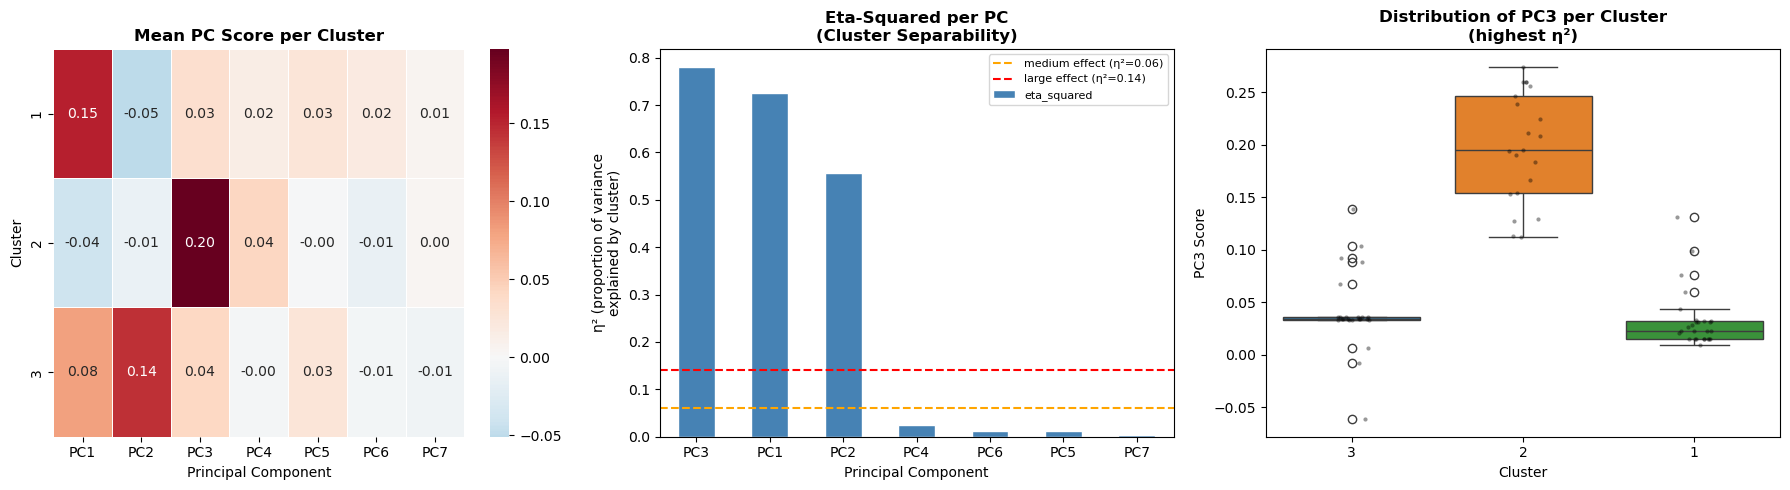


=== Tukey HSD post-hoc for PC3 ===
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
     1      2   0.1647    0.0  0.1369  0.1924   True
     1      3   0.0077 0.7721 -0.0191  0.0344  False
     2      3   -0.157    0.0 -0.1855 -0.1285   True
----------------------------------------------------


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

n_pcs = 7
n_samples = weights_e.shape[1]      # 72
clusters = np.unique(community_assignments_e)
# start with efferent connections

# ── 2. Build a tidy DataFrame ────────────────────────────────────────────────
pc_df = pd.DataFrame(
    weights_e.T,                              # (72 x 7)
    columns=[f"PC{i+1}" for i in range(n_pcs)]
)
pc_df["cluster"] = community_assignments_e.astype(str)

# ── 3. Summary statistics per cluster ───────────────────────────────────────
summary = (
    pc_df.groupby("cluster")
         .agg(["mean", "median", "std"])
)
print("=== Mean PC score per cluster ===")
mean_scores = pc_df.groupby("cluster").mean()
print(mean_scores.round(3))

# ── 4. ANOVA: which PCs significantly separate clusters? ────────────────────
print("\n=== ANOVA: F-statistic and p-value per PC ===")
anova_results = {}
for pc in [f"PC{i+1}" for i in range(n_pcs)]:
    groups = [pc_df.loc[pc_df["cluster"] == str(c), pc].values for c in clusters]
    f_stat, p_val = stats.f_oneway(*groups)
    anova_results[pc] = {"F-statistic": f_stat, "p-value": p_val}

anova_df = pd.DataFrame(anova_results).T
anova_df["significant"] = anova_df["p-value"] < 0.05
print(anova_df.round(4))

# ── 5. Eta-squared (effect size): variance explained by cluster per PC ───────
print("\n=== Eta-squared (effect size) per PC ===")
eta_sq = {}
for pc in [f"PC{i+1}" for i in range(n_pcs)]:
    grand_mean = pc_df[pc].mean()
    ss_between = sum(
        len(pc_df[pc_df["cluster"] == str(c)]) *
        (pc_df[pc_df["cluster"] == str(c)][pc].mean() - grand_mean) ** 2
        for c in clusters
    )
    ss_total = ((pc_df[pc] - grand_mean) ** 2).sum()
    eta_sq[pc] = ss_between / ss_total

eta_df = pd.Series(eta_sq, name="eta_squared").sort_values(ascending=False)
print(eta_df.round(4))

# ── 6. Visualisations ────────────────────────────────────────────────────────
palette = sns.color_palette("tab10", len(clusters))

# 6a. Heatmap — mean PC score per cluster
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.heatmap(
    mean_scores,
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    linewidths=0.5, ax=axes[0]
)
axes[0].set_title("Mean PC Score per Cluster", fontweight="bold")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Cluster")

# 6b. Bar chart — eta-squared (which PCs best separate clusters?)
eta_df.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white")
axes[1].axhline(0.06, color="orange", linestyle="--", label="medium effect (η²=0.06)")
axes[1].axhline(0.14, color="red",    linestyle="--", label="large effect (η²=0.14)")
axes[1].set_title("Eta-Squared per PC\n(Cluster Separability)", fontweight="bold")
axes[1].set_xlabel("Principal Component")
axes[1].set_ylabel("η² (proportion of variance\nexplained by cluster)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
axes[1].legend(fontsize=8)

# 6c. Box plot — distribution of the most discriminating PC
best_pc = eta_df.index[0]
sns.boxplot(
    data=pc_df, x="cluster", y=best_pc,
    palette=palette, ax=axes[2]
)
sns.stripplot(
    data=pc_df, x="cluster", y=best_pc,
    color="black", alpha=0.4, size=3, ax=axes[2]
)
axes[2].set_title(f"Distribution of {best_pc} per Cluster\n(highest η²)", fontweight="bold")
axes[2].set_xlabel("Cluster")
axes[2].set_ylabel(f"{best_pc} Score")

plt.tight_layout()
plt.savefig("pc_cluster_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7. Pairwise post-hoc: Tukey HSD for the best-separating PC ──────────────
from statsmodels.stats.multicomp import pairwise_tukeyhsd

print(f"\n=== Tukey HSD post-hoc for {best_pc} ===")
tukey = pairwise_tukeyhsd(
    endog=pc_df[best_pc],
    groups=pc_df["cluster"],
    alpha=0.05
)
print(tukey)